In [ ]:
import re
import numpy as np

def parse_caracteres_h(path: str):
    """
    Convierte los caracteres de datos.txt en un array (N,7,5) de 0 y 1.
    """
    text = open(path, 'r', encoding='latin1').read()
    matches = re.findall(r"\{([^{}]+)\}", text)
    images = []
    for m in matches:
        # Convertir cada número hexadecimal a int
        nums = [int(x,16) if 'x' in x else int(x) for x in m.split(',') if x.strip()]
        if len(nums) == 7:  # cada carácter tiene 7 filas
            img = np.zeros((7,5), dtype=np.float32)
            for r,v in enumerate(nums):
                for c in range(5):
                    img[r,4-c] = (v >> c) & 1
            images.append(img)
    images = np.array(images, dtype=np.float32)
    return images, (7,5)

# Cargar los caracteres
images, (H,W) = parse_caracteres_h('datos.txt')
images = np.expand_dims(images, -1)  # añade canal para Keras
print("Dataset shape:", images.shape)  # debe mostrar (32,7,5,1) caracteres filas columnas canales

Dataset shape: (32, 7, 5, 1)


In [ ]:
from tensorflow.keras import layers, models

# Autoencoder denso para imágenes 7x5
inputs = layers.Input(shape=(7,5,1))
x = layers.Flatten()(inputs)
x = layers.Dense(22, activation='relu')(x)  # capa intermedia
latent = layers.Dense(2, name='latent')(x)  # espacio latente 2D

encoder = models.Model(inputs, latent)

# Decoder simétrico
latent_inputs = layers.Input(shape=(2,))
x = layers.Dense(22, activation='relu')(latent_inputs)
x = layers.Dense(7*5, activation='sigmoid')(x)
outputs = layers.Reshape((7,5,1))(x)

decoder = models.Model(latent_inputs, outputs)

# Autoencoder completo
autoencoder = models.Model(inputs, decoder(encoder(inputs)))
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.summary()

Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 7, 5, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_16 (Functional)      │ (None, 2)              │           838 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_17 (Functional)      │ (None, 7, 5, 1)        │           871 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,709 (6.68 KB)

 Trainable params: 1,709 (6.68 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenamiento
autoencoder.fit(
    images, images,          # entradas y salidas iguales
    epochs=200,              # más épocas por dataset pequeño
    batch_size=8,            # tamaño de batch pequeño
    shuffle=True
)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.6872
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.6829
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6784 
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6733 
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6691 
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6633 
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6570 
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6532 
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6487 
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6385 
Epoch 11/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6428
Epoch 12/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6240 
Epoch 13/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6193 
Epoch 14/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6222 
Epoch 15/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5998 
Epoch 16/200
4/4 ━

In [ ]:
import re
import matplotlib.pyplot as plt

# --------------------- Obtener etiquetas reales ----------------------
def obtener_labels(path: str):
    """
    Extrae el carácter real de cada comentario en datos.txt.
    Por ejemplo: '// 0x40, @' -> '@'
    """
    text = open(path, 'r', encoding='latin1').read()
    # Tomar el carácter después de la coma en el comentario
    matches = re.findall(r'//.*,\s*(.)', text)
    return matches

labels = obtener_labels('datos.txt')
print("Etiquetas:", labels)  # ['@', 'A', 'B', 'C', ...]



Etiquetas: ['@', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '[', '\\', ']', '^', '_']


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


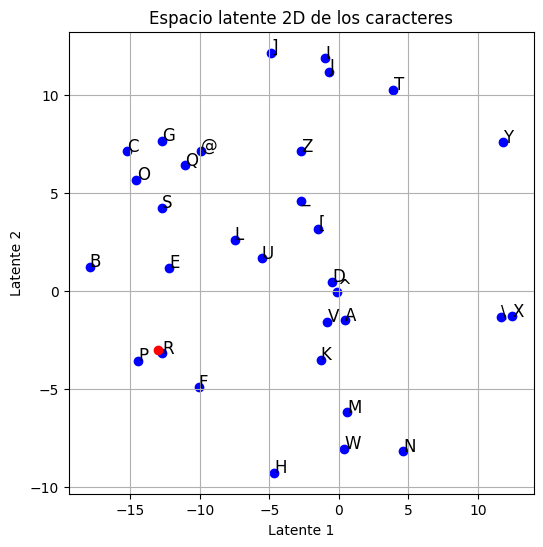

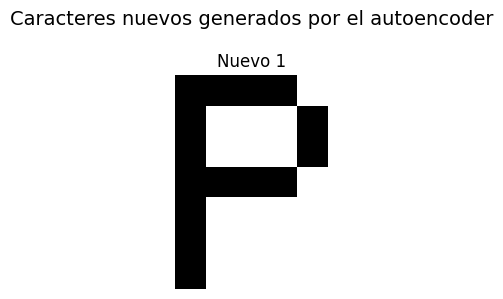

In [ ]:
# --------------------- Graficar espacio latente ----------------------
# latents: salida del encoder después del entrenamiento
latents = encoder.predict(images)  # shape (32,2)
# Crear 8 puntos nuevos en el espacio latente (fuera del rango usual)
latent_samples = np.array([[-13, -3]])  # shape (1, 2)

# Generar caracteres con el decodificador
generados = decoder.predict(latent_samples)
generados = (generados > 0.5).astype(np.float32)
plt.figure(figsize=(6,6))
plt.scatter(latents[:,0], latents[:,1], c='blue')
plt.scatter(latent_samples[:,0], latent_samples[:,1], c="red")
# Etiquetar cada punto con el carácter real
for i, label in enumerate(labels):
    plt.text(latents[i,0]+0.01, latents[i,1]+0.01, label, fontsize=12)

plt.title("Espacio latente 2D de los caracteres")
plt.xlabel("Latente 1")
plt.ylabel("Latente 2")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 3))
for i in range(len(generados)):
    plt.subplot(1, len(generados), i+1)
    plt.imshow(generados[i].squeeze(), cmap='gray_r')
    plt.axis('off')
    plt.title(f"Nuevo {i+1}")
plt.suptitle("Caracteres nuevos generados por el autoencoder", fontsize=14)
plt.tight_layout()
plt.show()

2)Elección de la arquitectura

Dense 128 → 32 → 128: permite capturar patrones en la imagen sin overfitting, dado que los datos son pequeños.

Latent de tamaño 32: suficientemente grande para codificar los caracteres completos, pero pequeño para obligar a la red a aprender la estructura y no memorizar ruido.

Sigmoid + BCE: reconstruimos píxeles binarios.

In [ ]:
from tensorflow.keras import layers, models, optimizers

inputs = layers.Input(shape=(7,5,1))
x = layers.Flatten()(inputs)

# Encoder
x = layers.Dense(32, activation='relu')(x)  # capa más grande para aprender patrones
x = layers.Dense(16, activation='relu')(x)
x = layers.Dense(8, activation='relu')(x)
latent = layers.Dense(4)(x)  # representación intermedia

# Decoder
x = layers.Dense(8, activation='relu')(latent)
x = layers.Dense(16, activation='relu')(x)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dense(7*5, activation='sigmoid')(x)
outputs = layers.Reshape((7,5,1))(x)

denoiser = models.Model(inputs, outputs)
# Creamos Adam con tasa de aprendizaje personalizada
adam_custom = optimizers.Adam(learning_rate=0.01)  # podés cambiar 0.001 por lo que quieras
denoiser.compile(optimizer= adam_custom , loss='binary_crossentropy')
denoiser.summary()

Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 7, 5, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 35)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 32)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 35)             │         1,155 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_10 (Reshape)            │ (None, 7, 5, 1)        │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,735 (14.59 KB)

 Trainable params: 3,735 (14.59 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# --- Función de ruido ---
def add_noise(images, noise_level=0.2):
    noisy = images.copy()
    mask = np.random.rand(*images.shape) < noise_level
    noisy[mask] = 1 - noisy[mask]
    return noisy

# --- Entrenamiento ---
epochs = 600
batch_size = 8

for epoch in range(epochs):
    # generar nuevo ruido cada época (nivel aleatorio entre 0.05 y 0.2)
    noise_level = np.random.uniform(0.05, 0.2)
    X_noisy = add_noise(images, noise_level)
    denoiser.fit(X_noisy, images,
                 batch_size=batch_size,
                 epochs=1)
    if (epoch+1) % 50 == 0:
        print(f"Época {epoch+1}/{epochs} completada (ruido {noise_level:.2f})")
denoiser.save("denoiser_model.h5")

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.6904
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6631 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6343 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5830 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5809 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5597 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5559
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5481 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5161 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4864 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5005 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5057 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4831 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4851 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4516 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4711 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4229 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4237 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0

Época 600/600 completada (ruido 0.16)


Se guarda el Modelo y se lo deja listo para agregarle de a 400 epocas de ser necesario con taza de aprendizaje variable para poder disminuir el error lo mejor posible

In [ ]:
import tensorflow as tf

# (1) Cargar el modelo guardado
from tensorflow.keras.models import load_model
denoiser = load_model("denoiser_model.h5")

# (2) Asegurar ejecución eager y recompilar el modelo
tf.config.run_functions_eagerly(True)

# (3) Recompilar el modelo (necesario después de cargar)
new_lr = 0.001
denoiser.compile(optimizer=Adam(learning_rate=new_lr), loss='binary_crossentropy')
print("Modelo cargado y recompilado correctamente. Listo para seguir entrenando.")

# ✅ (4) Volver al modo rápido (opcional pero recomendable si ya funciona)
tf.config.run_functions_eagerly(False)

# Definir el resto del entrenamiento
extra_epochs = 400
batch_size = 8

for epoch in range(extra_epochs):
    noise_level = np.random.uniform(0.05, 0.2)
    X_noisy = add_noise(images, noise_level)
    denoiser.fit(X_noisy, images,
                 batch_size=batch_size,
                 epochs=1)
    if (epoch+1) % 50 == 0:
        print(f"Época extra {epoch+1}/{extra_epochs} completada (ruido {noise_level:.2f})")

# Volver a guardar el modelo actualizado
denoiser.save("denoiser_model.h5")


Modelo cargado y recompilado correctamente. Listo para seguir entrenando.
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1474
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1359
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1288
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1066
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1706
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1565
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1032
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2478
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1593
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1793 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1201 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0961 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0942 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2097 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0978 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0811 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0903 
4/4 ━━━━━━━━━━━━━━━━━━━━ 

Época extra 400/400 completada (ruido 0.10)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


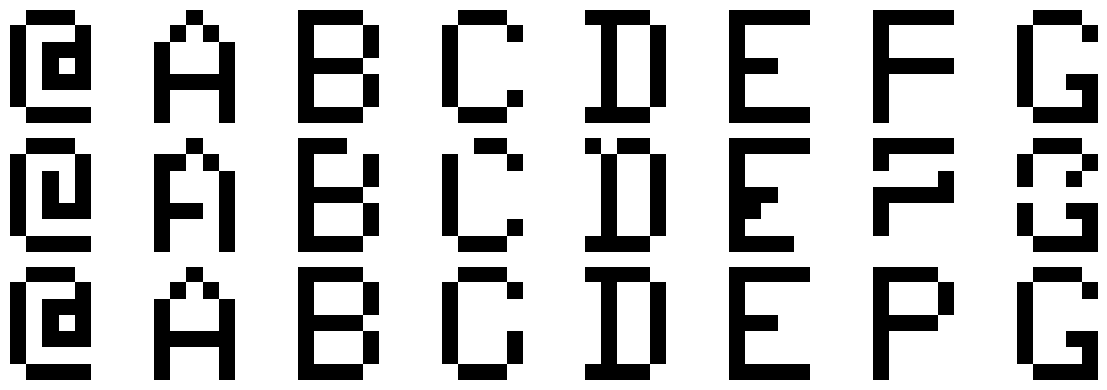

In [ ]:
#despues de entrenar ahora vemos como la red puede limpiar el ruido
# Tomamos algunas imágenes ruidosas
test_noisy = add_noise(images[:8], noise_level=0.05) #aca va el porcentaje de ruido

# Reconstruimos
cleaned = denoiser.predict(test_noisy)
cleaned = (cleaned > 0.5).astype(np.float32)
# Mostrar comparativa
plt.figure(figsize=(12,4))
for i in range(8):
    plt.subplot(3,8,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray_r')
    plt.axis('off')
    if i==0: plt.ylabel("Original", fontsize=10)

    plt.subplot(3,8,8+i+1)
    plt.imshow(test_noisy[i].squeeze(), cmap='gray_r')
    plt.axis('off')
    if i==0: plt.ylabel("Ruidosa", fontsize=10)

    plt.subplot(3,8,16+i+1)
    plt.imshow(cleaned[i].squeeze(), cmap='gray_r')
    plt.axis('off')
    if i==0: plt.ylabel("Limpia", fontsize=10)

plt.tight_layout()
plt.show()

Con 32 caracteres de 7×5 píxeles, la red prácticamente memoriza los datos.

Esto hace que cualquier ruido aleatorio (aunque sea 10-30%) desestabilice la reconstrucción.
Al aplicar un 30% de ruido, estamos invirtiendo casi 11 píxeles de un total de 35

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, clear_output

# -------------------- 1️⃣ Cargar emojis en blanco y negro --------------------
def load_emoji_gray(path, size=(32,32)):
    img = Image.open(path).convert('L').resize(size)  # Abrir imagen, convertir a escala de grises y redimensionar
    return np.array(img, dtype=np.float32)/255.0       # Normalizar píxeles a [0,1]

# Cargar tus 4 emojis
emoji_paths = ["emoji_babeando.png","emoji_happy.png", "emoji_sad.png", "emoji_angry.png", "emoji_surprised.png","emoji_risa.png","emoji_smiley.png","emoji_lentes.png"]
emojis = np.array([load_emoji_gray(p) for p in emoji_paths])  # Crear array con las 4 imágenes
emojis = np.expand_dims(emojis, -1)                            # Añadir dimensión de canal (necesario para Keras)
print("Dataset shape:", emojis.shape)                          # Mostrar forma del dataset (4,32,32,1)

# -------------------- 2️⃣ Autoencoder denso --------------------
inputs = layers.Input(shape=(32,32,1))                         # Input de 32x32x1
x = layers.Flatten()(inputs)                                    # Aplanar la imagen a vector de 1024
x = layers.Dense(512, activation='relu')(x)                    # Capa densa intermedia con 512 neuronas
latent = layers.Dense(2, name='latent')(x)                     # Latent space 2D

encoder = models.Model(inputs, latent)                         # Modelo encoder

# Decoder simétrico
latent_inputs = layers.Input(shape=(2,))                        # Input del decoder (latent 2D)
x = layers.Dense(512, activation='relu')(latent_inputs)        # Capa densa para decodificar
x = layers.Dense(32*32, activation='sigmoid')(x)               # Output aplanado de 1024 valores entre 0 y 1
outputs = layers.Reshape((32,32,1))(x)                         # Volver a forma 32x32x1
decoder = models.Model(latent_inputs, outputs)                 # Modelo decoder

# Autoencoder completo
autoencoder = models.Model(inputs, decoder(encoder(inputs)))   # Conectar encoder y decoder
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy')  # Compilar con Adam y pérdida binaria
autoencoder.summary()                                          # Mostrar arquitectura

# -------------------- 3️⃣ Entrenamiento --------------------
autoencoder.fit(emojis, emojis, epochs=400, verbose=1)        # Entrenar para reconstruir las mismas imágenes
print("✅ Entrenamiento completado")

# -------------------- 4️⃣ Latent space real de los emojis --------------------
latents_real = encoder.predict(emojis)                         # Obtener coordenadas latentes de los emojis reales
print("Latent points reales:\n", latents_real)

# -------------------- 5️⃣ Función interactiva --------------------
def update_plot(x, y):
    latent_point = np.array([[x, y]])                           # Crear punto latente a partir de sliders
    generated = decoder.predict(latent_point, verbose=0)        # Generar imagen decodificada
    clear_output(wait=True)                                     # Limpiar output anterior para actualizar plot

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7,3))        # Crear 2 subplots: espacio latente + imagen generada

    # Espacio latente con puntos reales
    colors = ['yellow','blue','red','green','orange','purple','cyan','pink'] # Colores para cada emoji
    labels = ["Babeando","Happy","Sad","Angry","Surprised","Risa","Smiley","Lentes"] # Nombres de los emojis
    ax1.scatter(latents_real[:,0], latents_real[:,1], c=colors, s=100)  # Dibujar puntos reales
    ax1.scatter(x, y, c='black', marker='x', s=100)            # Dibujar punto actual del slider

    for i, label in enumerate(labels):
        ax1.text(latents_real[i,0]+0.05, latents_real[i,1]+0.05, label, fontsize=10)  # Etiquetar emojis

    ax1.set_xlim(latents_real[:,0].min()-0.5, latents_real[:,0].max()+0.5)  # Limites eje X
    ax1.set_ylim(latents_real[:,1].min()-0.5, latents_real[:,1].max()+0.5)  # Limites eje Y
    ax1.set_title("Espacio latente real")
    ax1.grid(True)

    # Emoji generado
    ax2.imshow(generated[0].squeeze(), cmap='gray_r')           # Mostrar imagen generada
    ax2.axis('off')                                             # Quitar ejes
    ax2.set_title(f"Emoji generado\n(x={x:.2f}, y={y:.2f})")

    plt.show()

# -------------------- 6️⃣ Sliders interactivos --------------------
x_slider = widgets.FloatSlider(
    value=float(latents_real[:,0].mean()),                     # Valor inicial = promedio latentes reales
    min=latents_real[:,0].min()-0.5,                           # Límite mínimo
    max=latents_real[:,0].max()+0.5,                           # Límite máximo
    step=0.01, description='Latente X'
)
y_slider = widgets.FloatSlider(
    value=float(latents_real[:,1].mean()),                     # Valor inicial = promedio latentes reales
    min=latents_real[:,1].min()-0.5,                           # Límite mínimo
    max=latents_real[:,1].max()+0.5,                           # Límite máximo
    step=0.01, description='Latente Y'
)

display(widgets.interactive(update_plot, x=x_slider, y=y_slider))  # Mostrar sliders interactivos


Dataset shape: (8, 32, 32, 1)


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_4 (Functional)       │ (None, 2)              │       525,826 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_5 (Functional)       │ (None, 32, 32, 1)      │       526,848 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,052,674 (4.02 MB)

 Trainable params: 1,052,674 (4.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.6941
Epoch 2/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.7021
Epoch 3/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.6760
Epoch 4/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.6403
Epoch 5/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.5990
Epoch 6/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.5623
Epoch 7/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.5382
Epoch 8/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.5237
Epoch 9/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.5089
Epoch 10/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.4939
Epoch 11/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.4832
Epoch 12/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.4792
Epoch 13/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.4802
Epoch 14/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 0.4826
Epoch 15/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.4836
Epoch 16/400
1/1 ━━━

interactive(children=(FloatSlider(value=2.3781721591949463, description='Latente X', max=15.923617362976074, m…